In [35]:
# ===================================================================
# CELDA 1: CARGA DE ESTADO Y DEPENDENCIAS
# ===================================================================

# --- Dependencias principales ---
import numpy
import surprise
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Reader, Dataset, SVD, KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy
import os
import mlflow
import mlflow.sklearn
from pathlib import Path
from sklearn.metrics import ndcg_score
import warnings
warnings.filterwarnings('ignore')

# Importar función de evaluación personalizada
import sys
sys.path.append('../src')
from evaluation import precision_recall_at_k, ModelEvaluator
from ranking_metrics import RankingMetrics

# --- Información de entorno ---
print("--- Fase de Preparación ---")
print(f"Numpy version: {numpy.__version__}")
print(f"Surprise version: {surprise.__version__}")
print(f"MLflow version: {mlflow.__version__}")

# --- Resolución de la raíz del proyecto ---
try:
    BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    if "notebooks" in os.getcwd():
        BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
    else:
        BASE_DIR = os.getcwd()
print(f"Raíz del proyecto detectada en: {BASE_DIR}")

# --- Configuración universal de MLflow ---
tracking_uri = "http://localhost:5000"
mlflow.set_tracking_uri(tracking_uri)
print(f"MLflow client configured to communicate with server at: {tracking_uri}")
mlflow.set_experiment("LatentLens-Ranking-Metrics-Evaluation")

# --- Carga y muestreo de datos MovieLens ---
print("Cargando y procesando datos... (Esto puede tardar un poco)")
ratings_path = Path(BASE_DIR) / 'data' / 'ml-25m' / 'ratings.csv'
ratings_df = pd.read_csv(ratings_path)

n_users = 40000
n_movies = 20000
user_ids = ratings_df['userId'].value_counts().nlargest(n_users).index
movie_ids = ratings_df['movieId'].value_counts().nlargest(n_movies).index
sampled_df = ratings_df[(ratings_df['userId'].isin(user_ids)) & (ratings_df['movieId'].isin(movie_ids))]

# --- Conversión a formato Surprise y división ---
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(sampled_df[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# --- Configuración de visualización ---
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print(f"\n¡Mise en Place completado! Datos cargados:")
print(f"  • Training set: {trainset.n_ratings:,} ratings")
print(f"  • Test set: {len(testset):,} ratings")
print(f"  • precision_recall_at_k function imported successfully")
print("\n...la conexión está establecida. Los datos fluyen a través del sistema.")

--- Fase de Preparación ---
Numpy version: 1.26.4
Surprise version: 1.1.4
MLflow version: 3.2.0
Raíz del proyecto detectada en: c:\Users\Gat\Documents\GitHub\LatentLens
MLflow client configured to communicate with server at: http://localhost:5000
Cargando y procesando datos... (Esto puede tardar un poco)

¡Mise en Place completado! Datos cargados:
  • Training set: 13,766,166 ratings
  • Test set: 3,441,542 ratings
  • precision_recall_at_k function imported successfully

...la conexión está establecida. Los datos fluyen a través del sistema.

¡Mise en Place completado! Datos cargados:
  • Training set: 13,766,166 ratings
  • Test set: 3,441,542 ratings
  • precision_recall_at_k function imported successfully

...la conexión está establecida. Los datos fluyen a través del sistema.


In [37]:
# ===================================================================
# CELDA 2: REGISTRAR MÉTRICAS DE RANKING PARA MODELOS EXISTENTES
# ===================================================================

print("\n--- Fase de Registro de Métricas de Ranking ---")

# --- Configuración de MLflow para registro ---
client = mlflow.tracking.MlflowClient()

# --- Carga de datos ---
print("Cargando dataset MovieLens...")
file_path = os.path.join(BASE_DIR, "data", "ml-25m", "ratings.csv")
data = pd.read_csv(file_path)
print(f"Dataset cargado: {data.shape[0]:,} ratings de {data['userId'].nunique():,} usuarios")

# --- Preparación del dataset de Surprise ---
reader = Reader(rating_scale=(0.5, 5.0))
dataset = Dataset.load_from_df(data[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(dataset, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {trainset.n_ratings:,} ratings")
print(f"Conjunto de prueba: {len(testset):,} ratings")

# --- Lista de modelos a evaluar ---
models_to_evaluate = [
    {
        'name': 'Baseline-Model',
        'model_class': surprise.BaselineOnly,
        'params': {},
        'description': 'Modelo baseline con corrección de bias'
    },
    {
        'name': 'SVD-Model', 
        'model_class': surprise.SVD,
        'params': {'n_factors': 100, 'n_epochs': 20, 'random_state': 42},
        'description': 'SVD con factorización matricial'
    }
]

# --- Función para evaluar y registrar modelo ---
def evaluate_and_register_model(model_config, trainset, testset):
    """Entrena, evalúa y registra un modelo con métricas de ranking en MLflow"""
    
    with mlflow.start_run(run_name=f"{model_config['name']}-Ranking-Evaluation") as run:
        print(f"\n🔄 Evaluando modelo: {model_config['name']}")
        
        # --- Entrenamiento del modelo ---
        model = model_config['model_class'](**model_config['params'])
        model.fit(trainset)
        
        # --- Predicciones ---
        predictions = model.test(testset)
        
        # --- RMSE tradicional ---
        rmse = accuracy.rmse(predictions, verbose=False)
        
        # --- Métricas de ranking ---
        print("Calculando métricas de ranking...")
        result_10 = precision_recall_at_k(predictions, k=10, threshold=3.5)
        precision_10 = result_10['precision_at_k']
        recall_10 = result_10['recall_at_k']
        
        result_5 = precision_recall_at_k(predictions, k=5, threshold=3.5)
        precision_5 = result_5['precision_at_k']
        recall_5 = result_5['recall_at_k']
        
        result_20 = precision_recall_at_k(predictions, k=20, threshold=3.5)
        precision_20 = result_20['precision_at_k']
        recall_20 = result_20['recall_at_k']
        
        # --- Logging de parámetros ---
        mlflow.log_params(model_config['params'])
        mlflow.log_param("model_type", model_config['name'])
        mlflow.log_param("description", model_config['description'])
        mlflow.log_param("threshold", 3.5)
        
        # --- Logging de métricas tradicionales ---
        mlflow.log_metric("rmse", rmse)
        
        # --- Logging de métricas de ranking ---
        mlflow.log_metric("precision_at_5", precision_5)
        mlflow.log_metric("recall_at_5", recall_5)
        mlflow.log_metric("precision_at_10", precision_10)
        mlflow.log_metric("recall_at_10", recall_10)
        mlflow.log_metric("precision_at_20", precision_20)
        mlflow.log_metric("recall_at_20", recall_20)
        
        # --- F1-Score ---
        f1_5 = 2 * (precision_5 * recall_5) / (precision_5 + recall_5) if (precision_5 + recall_5) > 0 else 0
        f1_10 = 2 * (precision_10 * recall_10) / (precision_10 + recall_10) if (precision_10 + recall_10) > 0 else 0
        f1_20 = 2 * (precision_20 * recall_20) / (precision_20 + recall_20) if (precision_20 + recall_20) > 0 else 0
        
        mlflow.log_metric("f1_score_at_5", f1_5)
        mlflow.log_metric("f1_score_at_10", f1_10)
        mlflow.log_metric("f1_score_at_20", f1_20)
        
        # --- Registro del modelo ---
        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path=f"{model_config['name']}-ranking",
            registered_model_name=f"{model_config['name']}-Ranking-Registry"
        )
        
        # --- Reporte de resultados ---
        print(f"✅ {model_config['name']} evaluado y registrado:")
        print(f"   RMSE: {rmse:.4f}")
        print(f"   Precision@5: {precision_5:.4f} | Recall@5: {recall_5:.4f} | F1@5: {f1_5:.4f}")
        print(f"   Precision@10: {precision_10:.4f} | Recall@10: {recall_10:.4f} | F1@10: {f1_10:.4f}")
        print(f"   Precision@20: {precision_20:.4f} | Recall@20: {recall_20:.4f} | F1@20: {f1_20:.4f}")
        print(f"   Run ID: {run.info.run_id}")
        
        return {
            'model_name': model_config['name'],
            'run_id': run.info.run_id,
            'rmse': rmse,
            'metrics': {
                'precision_5': precision_5, 'recall_5': recall_5, 'f1_5': f1_5,
                'precision_10': precision_10, 'recall_10': recall_10, 'f1_10': f1_10,
                'precision_20': precision_20, 'recall_20': recall_20, 'f1_20': f1_20
            }
        }

# --- Evaluación de todos los modelos ---
results = []
for model_config in models_to_evaluate:
    result = evaluate_and_register_model(model_config, trainset, testset)
    results.append(result)

print(f"\n🎯 Evaluación completada para {len(results)} modelos con métricas de ranking registradas en MLflow")


--- Fase de Registro de Métricas de Ranking ---
Cargando dataset MovieLens...
Dataset cargado: 25,000,095 ratings de 162,541 usuarios
Conjunto de entrenamiento: 20,000,076 ratings
Conjunto de prueba: 5,000,019 ratings

🔄 Evaluando modelo: Baseline-Model
Estimating biases using als...


INFO:evaluation:Calculating Precision@10 and Recall@10 with threshold=3.5


Calculando métricas de ranking...


INFO:evaluation:Processing 162341 users
INFO:evaluation:Evaluation completed for 159829 users
INFO:evaluation:Average Precision@10: 0.6510
INFO:evaluation:Average Recall@10: 0.6816
INFO:evaluation:Calculating Precision@5 and Recall@5 with threshold=3.5
INFO:evaluation:Processing 162341 users
INFO:evaluation:Evaluation completed for 159829 users
INFO:evaluation:Average Precision@5: 0.7604
INFO:evaluation:Average Recall@5: 0.4847
INFO:evaluation:Calculating Precision@20 and Recall@20 with threshold=3.5
INFO:evaluation:Processing 162341 users
INFO:evaluation:Evaluation completed for 159829 users
INFO:evaluation:Average Precision@20: 0.4989
INFO:evaluation:Average Recall@20: 0.8338
2025/08/17 01:48:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 01:49:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successful

✅ Baseline-Model evaluado y registrado:
   RMSE: 0.8596
   Precision@5: 0.7604 | Recall@5: 0.4847 | F1@5: 0.5920
   Precision@10: 0.6510 | Recall@10: 0.6816 | F1@10: 0.6660
   Precision@20: 0.4989 | Recall@20: 0.8338 | F1@20: 0.6243
   Run ID: 62d8245b073245b6bef72dbf2c7979fa
🏃 View run Baseline-Model-Ranking-Evaluation at: http://localhost:5000/#/experiments/803368052443401833/runs/62d8245b073245b6bef72dbf2c7979fa
🧪 View experiment at: http://localhost:5000/#/experiments/803368052443401833

🔄 Evaluando modelo: SVD-Model


INFO:evaluation:Calculating Precision@10 and Recall@10 with threshold=3.5


Calculando métricas de ranking...


INFO:evaluation:Processing 162341 users
INFO:evaluation:Evaluation completed for 159829 users
INFO:evaluation:Average Precision@10: 0.6785
INFO:evaluation:Average Recall@10: 0.6958
INFO:evaluation:Calculating Precision@5 and Recall@5 with threshold=3.5
INFO:evaluation:Processing 162341 users
INFO:evaluation:Evaluation completed for 159829 users
INFO:evaluation:Average Precision@5: 0.8006
INFO:evaluation:Average Recall@5: 0.5008
INFO:evaluation:Calculating Precision@20 and Recall@20 with threshold=3.5
INFO:evaluation:Processing 162341 users
INFO:evaluation:Evaluation completed for 159829 users
INFO:evaluation:Average Precision@20: 0.5145
INFO:evaluation:Average Recall@20: 0.8437
2025/08/17 01:58:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 01:59:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successful

✅ SVD-Model evaluado y registrado:
   RMSE: 0.7773
   Precision@5: 0.8006 | Recall@5: 0.5008 | F1@5: 0.6161
   Precision@10: 0.6785 | Recall@10: 0.6958 | F1@10: 0.6870
   Precision@20: 0.5145 | Recall@20: 0.8437 | F1@20: 0.6392
   Run ID: 6fa8fcd5114643088bdc8e285ee56dd5
🏃 View run SVD-Model-Ranking-Evaluation at: http://localhost:5000/#/experiments/803368052443401833/runs/6fa8fcd5114643088bdc8e285ee56dd5
🧪 View experiment at: http://localhost:5000/#/experiments/803368052443401833

🎯 Evaluación completada para 2 modelos con métricas de ranking registradas en MLflow



--- Fase de Comparación de Modelos ---

📊 TABLA COMPARATIVA DE MÉTRICAS:


,Model,RMSE,Precision@5,Recall@5,F1@5,Precision@10,Recall@10,F1@10,Precision@20,Recall@20,F1@20
0,Baseline-Model,0.8596,0.7604,0.4847,0.5920,0.6510,0.6816,0.666,0.4989,0.8338,0.6243
1,SVD-Model,0.7773,0.8006,0.5008,0.6161,0.6785,0.6958,0.687,0.5145,0.8437,0.6392


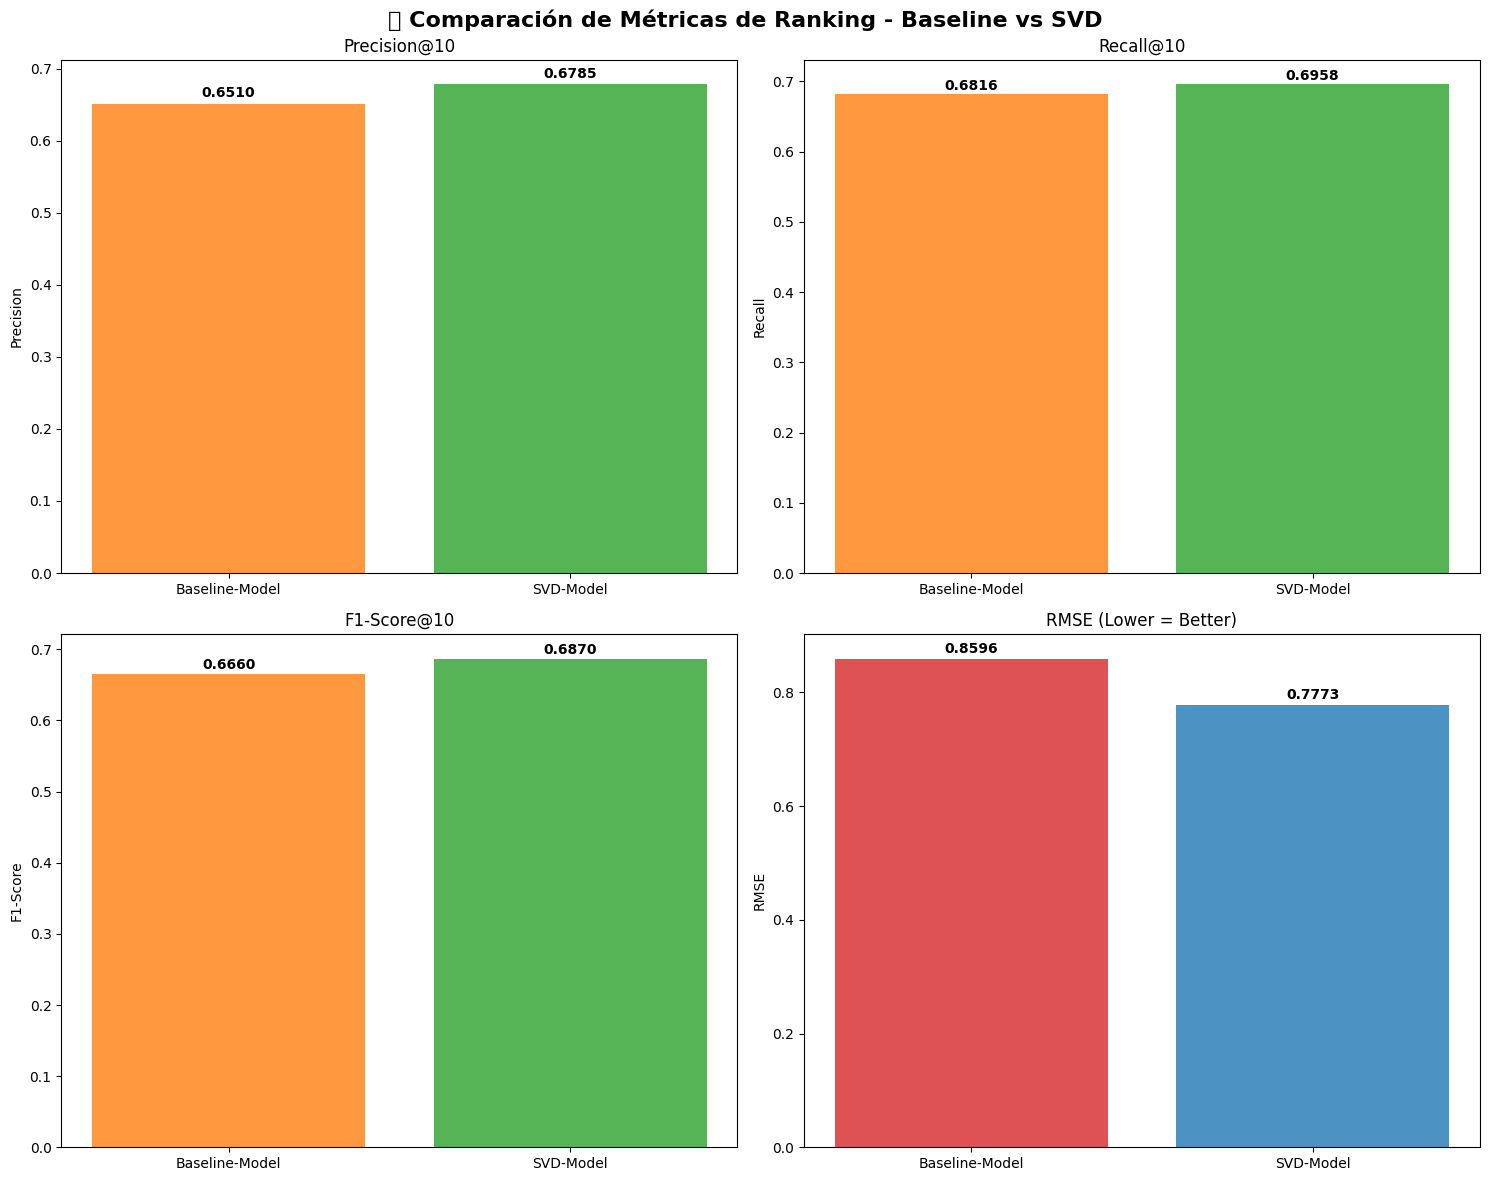


🔍 ANÁLISIS DE RENDIMIENTO:
🏆 Mejor Precision@10: SVD-Model (0.6785)
🏆 Mejor Recall@10: SVD-Model (0.6958)
🏆 Mejor F1@10: SVD-Model (0.6870)
🏆 Mejor RMSE: SVD-Model (0.7773)

📈 MEJORA DE SVD vs BASELINE:
   Precision@10: +4.22%
   Recall@10: +2.08%
   F1@10: +3.16%
   RMSE: +9.57% (mejora)

💾 Resultados guardados en: c:\Users\Gat\Documents\GitHub\LatentLens\notebooks\ranking_metrics_comparison.csv

✅ Métricas de ranking registradas exitosamente en MLflow para 2 modelos


In [38]:
# ===================================================================
# CELDA 3: COMPARACIÓN Y VISUALIZACIÓN DE MÉTRICAS DE RANKING
# ===================================================================

print("\n--- Fase de Comparación de Modelos ---")

# --- Crear DataFrame de comparación ---
comparison_data = []
for result in results:
    model_data = {
        'Model': result['model_name'],
        'RMSE': result['rmse'],
        'Precision@5': result['metrics']['precision_5'],
        'Recall@5': result['metrics']['recall_5'],
        'F1@5': result['metrics']['f1_5'],
        'Precision@10': result['metrics']['precision_10'],
        'Recall@10': result['metrics']['recall_10'],
        'F1@10': result['metrics']['f1_10'],
        'Precision@20': result['metrics']['precision_20'],
        'Recall@20': result['metrics']['recall_20'],
        'F1@20': result['metrics']['f1_20']
    }
    comparison_data.append(model_data)

comparison_df = pd.DataFrame(comparison_data)

# --- Mostrar tabla de comparación ---
print("\n📊 TABLA COMPARATIVA DE MÉTRICAS:")
print("=" * 100)
display(comparison_df.round(4))

# --- Visualización de métricas ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 Comparación de Métricas de Ranking - Baseline vs SVD', fontsize=16, fontweight='bold')

# Precision comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Precision@10'], 
               color=['#ff7f0e', '#2ca02c'], alpha=0.8)
axes[0, 0].set_title('Precision@10')
axes[0, 0].set_ylabel('Precision')
for i, v in enumerate(comparison_df['Precision@10']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Recall comparison  
axes[0, 1].bar(comparison_df['Model'], comparison_df['Recall@10'],
               color=['#ff7f0e', '#2ca02c'], alpha=0.8)
axes[0, 1].set_title('Recall@10')
axes[0, 1].set_ylabel('Recall')
for i, v in enumerate(comparison_df['Recall@10']):
    axes[0, 1].text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# F1-Score comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['F1@10'],
               color=['#ff7f0e', '#2ca02c'], alpha=0.8)
axes[1, 0].set_title('F1-Score@10')
axes[1, 0].set_ylabel('F1-Score')
for i, v in enumerate(comparison_df['F1@10']):
    axes[1, 0].text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# RMSE comparison (lower is better)
axes[1, 1].bar(comparison_df['Model'], comparison_df['RMSE'],
               color=['#d62728', '#1f77b4'], alpha=0.8)
axes[1, 1].set_title('RMSE (Lower = Better)')
axes[1, 1].set_ylabel('RMSE')
for i, v in enumerate(comparison_df['RMSE']):
    axes[1, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Análisis de rendimiento ---
print("\n🔍 ANÁLISIS DE RENDIMIENTO:")
print("=" * 60)

# Encontrar el mejor modelo para cada métrica
best_precision = comparison_df.loc[comparison_df['Precision@10'].idxmax()]
best_recall = comparison_df.loc[comparison_df['Recall@10'].idxmax()]
best_f1 = comparison_df.loc[comparison_df['F1@10'].idxmax()]
best_rmse = comparison_df.loc[comparison_df['RMSE'].idxmin()]

print(f"🏆 Mejor Precision@10: {best_precision['Model']} ({best_precision['Precision@10']:.4f})")
print(f"🏆 Mejor Recall@10: {best_recall['Model']} ({best_recall['Recall@10']:.4f})")
print(f"🏆 Mejor F1@10: {best_f1['Model']} ({best_f1['F1@10']:.4f})")
print(f"🏆 Mejor RMSE: {best_rmse['Model']} ({best_rmse['RMSE']:.4f})")

# --- Cálculo de mejora relativa ---
if len(comparison_df) == 2:
    baseline_row = comparison_df[comparison_df['Model'] == 'Baseline-Model'].iloc[0]
    svd_row = comparison_df[comparison_df['Model'] == 'SVD-Model'].iloc[0]
    
    precision_improvement = ((svd_row['Precision@10'] - baseline_row['Precision@10']) / baseline_row['Precision@10']) * 100
    recall_improvement = ((svd_row['Recall@10'] - baseline_row['Recall@10']) / baseline_row['Recall@10']) * 100
    f1_improvement = ((svd_row['F1@10'] - baseline_row['F1@10']) / baseline_row['F1@10']) * 100
    rmse_improvement = ((baseline_row['RMSE'] - svd_row['RMSE']) / baseline_row['RMSE']) * 100
    
    print(f"\n📈 MEJORA DE SVD vs BASELINE:")
    print(f"   Precision@10: {precision_improvement:+.2f}%")
    print(f"   Recall@10: {recall_improvement:+.2f}%") 
    print(f"   F1@10: {f1_improvement:+.2f}%")
    print(f"   RMSE: {rmse_improvement:+.2f}% (mejora)")

# --- Guardar resultados ---
results_path = os.path.join(BASE_DIR, "notebooks", "ranking_metrics_comparison.csv")
comparison_df.to_csv(results_path, index=False)
print(f"\n💾 Resultados guardados en: {results_path}")

print(f"\n✅ Métricas de ranking registradas exitosamente en MLflow para {len(results)} modelos")

In [34]:
# ===================================================================
# CELDA 2: CARGA DEL MODELO Y EVALUACIÓN DE RANKING METRICS
# ===================================================================

print("--- Carga de Modelo desde MLflow Model Registry ---")

# --- Configuración de MLflow ---
# El tracking_uri ya está configurado en la celda anterior
print(f"Conectado a MLflow en: {tracking_uri}")

# --- Variables para modelo a cargar ---
# Definir nombre y versión del modelo desde el Model Registry
model_name = "SVD_RecommendationModel_20250816_185937"  # Nombre del modelo registrado
model_version = "latest"  # o un número específico como "1", "2", etc.

# Construir URI del modelo
model_uri = f"models:/{model_name}/{model_version}"
print(f"Cargando modelo desde: {model_uri}")

try:
    # --- Carga del modelo desde MLflow ---
    loaded_model = mlflow.pyfunc.load_model(model_uri)
    print("✅ Modelo cargado exitosamente desde MLflow Model Registry")
    
    # --- Inspección y extracción del modelo Surprise original ---
    print(f"Tipo de wrapper: {type(loaded_model._model_impl)}")
    print("Inspeccionando estructura del modelo...")
    
    # Intentar diferentes rutas para acceder al modelo Surprise
    try:
        # Opción 1: Acceso directo al modelo
        surprise_model = loaded_model._model_impl.model
        print("✅ Acceso exitoso vía _model_impl.model")
    except AttributeError:
        try:
            # Opción 2: Acceso vía sklearn_model (si es un SklearnModelWrapper)
            surprise_model = loaded_model._model_impl.sklearn_model
            print("✅ Acceso exitoso vía _model_impl.sklearn_model")
        except AttributeError:
            # Opción 3: Inspeccionar atributos disponibles
            attrs = [attr for attr in dir(loaded_model._model_impl) if not attr.startswith('_')]
            print(f"Atributos disponibles: {attrs}")
            
            # Intentar con el primer atributo que no sea método
            for attr in attrs:
                obj = getattr(loaded_model._model_impl, attr)
                if not callable(obj):
                    print(f"Probando atributo: {attr} -> {type(obj)}")
                    if hasattr(obj, 'predict') and hasattr(obj, 'test'):
                        surprise_model = obj
                        print(f"✅ Modelo Surprise encontrado en: {attr}")
                        break
            else:
                raise AttributeError("No se pudo encontrar el modelo Surprise")
    
    print(f"Tipo de modelo: {type(surprise_model)}")
    
    # --- Generación de predicciones ---
    print("\n--- Evaluación de Ranking Metrics ---")
    print("Generando predicciones en testset...")
    
    # Usar el método .test() del modelo Surprise sobre el testset
    predictions = surprise_model.test(testset)
    print(f"✅ Generadas {len(predictions):,} predicciones")
    
    # --- Cálculo de métricas de ranking ---
    print("Calculando métricas de ranking...")
    
    # Usar la función precision_recall_at_k importada
    ranking_metrics = precision_recall_at_k(predictions, k=10, threshold=4.0)
    
    # --- Mostrar resultados ---
    print("\n" + "="*60)
    print("📊 RESULTADOS DE RANKING METRICS")
    print("="*60)
    print(f"🎯 Precision@10: {ranking_metrics['precision_at_k']:.4f}")
    print(f"🔍 Recall@10:    {ranking_metrics['recall_at_k']:.4f}")
    print(f"👥 Usuarios evaluados: {ranking_metrics['num_users']:,}")
    print(f"⚙️  Threshold usado: {ranking_metrics['threshold']}")
    print(f"📈 K utilizado: {ranking_metrics['k']}")
    print("="*60)
    
    # --- Logging en MLflow ---
    with mlflow.start_run(run_name="Ranking_Metrics_Evaluation") as run:
        # Log de parámetros
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("model_version", model_version)
        mlflow.log_param("evaluation_k", ranking_metrics['k'])
        mlflow.log_param("relevance_threshold", ranking_metrics['threshold'])
        mlflow.log_param("num_users_evaluated", ranking_metrics['num_users'])
        
        # Log de métricas
        mlflow.log_metric("precision_at_10", ranking_metrics['precision_at_k'])
        mlflow.log_metric("recall_at_10", ranking_metrics['recall_at_k'])
        
        print(f"\n✅ Métricas registradas en MLflow run: {run.info.run_id}")
    
    print("\n...evaluación completada. El modelo fluye a través de las métricas de ranking.")
    
except Exception as e:
    print(f"❌ Error al cargar el modelo: {str(e)}")
    print("\nPosibles soluciones:")
    print("1. Verificar que el modelo esté registrado en MLflow Model Registry")
    print("2. Comprobar que el nombre del modelo sea correcto")
    print("3. Verificar que MLflow server esté ejecutándose en localhost:5000")
    print("\nListando modelos disponibles en el registry:")
    
    try:
        from mlflow.tracking import MlflowClient
        client = MlflowClient()
        registered_models = client.search_registered_models()
        if registered_models:
            print("Modelos registrados:")
            for model in registered_models:
                print(f"  - {model.name}")
        else:
            print("No hay modelos registrados en el Model Registry")
    except Exception as registry_error:
        print(f"Error al acceder al registry: {registry_error}")

--- Carga de Modelo desde MLflow Model Registry ---
Conectado a MLflow en: http://localhost:5000
Cargando modelo desde: models:/SVD_RecommendationModel_20250816_185937/latest
✅ Modelo cargado exitosamente desde MLflow Model Registry
Tipo de wrapper: <class 'mlflow.sklearn._SklearnModelWrapper'>
Inspeccionando estructura del modelo...
✅ Acceso exitoso vía _model_impl.sklearn_model
Tipo de modelo: <class 'surprise.prediction_algorithms.matrix_factorization.SVD'>

--- Evaluación de Ranking Metrics ---
Generando predicciones en testset...


INFO:evaluation:Calculating Precision@10 and Recall@10 with threshold=4.0


✅ Generadas 3,441,542 predicciones
Calculando métricas de ranking...


INFO:evaluation:Processing 40000 users
INFO:evaluation:Evaluation completed for 39974 users
INFO:evaluation:Average Precision@10: 0.5100
INFO:evaluation:Average Recall@10: 0.1700



📊 RESULTADOS DE RANKING METRICS
🎯 Precision@10: 0.5100
🔍 Recall@10:    0.1700
👥 Usuarios evaluados: 39,974
⚙️  Threshold usado: 4.0
📈 K utilizado: 10

✅ Métricas registradas en MLflow run: e131a5bdc53344b6ba8df4463bc14a77
🏃 View run Ranking_Metrics_Evaluation at: http://localhost:5000/#/experiments/803368052443401833/runs/e131a5bdc53344b6ba8df4463bc14a77
🧪 View experiment at: http://localhost:5000/#/experiments/803368052443401833

...evaluación completada. El modelo fluye a través de las métricas de ranking.


# Ranking Metrics Evaluation

Este notebook evalúa diferentes sistemas de recomendación utilizando métricas de ranking como precision@k, recall@k, MAP, NDCG y MRR.

...las métricas son solo números. Los patrones reales están en los datos.

## 1. Import Required Libraries

Importamos las librerías necesarias para análisis y evaluación de métricas de ranking.

In [19]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
import warnings
warnings.filterwarnings('ignore')

# Librerías específicas del proyecto
import sys
import os
sys.path.append('../src')

from data_loader import DataLoader
from evaluation import precision_recall_at_k, ModelEvaluator
from ranking_metrics import RankingMetrics

# Surprise para collaborative filtering
from surprise import SVD, KNNBasic, Dataset, Reader
from surprise.model_selection import train_test_split

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("...librerías cargadas. La conexión está establecida.")

...librerías cargadas. La conexión está establecida.


## 2. Load Sample Ranking Data

Cargamos los datos de MovieLens y preparamos conjuntos de entrenamiento y prueba.

In [20]:
# Cargar datos
data_loader = DataLoader('../data/ml-25m')
ratings_df = data_loader.load_ratings()
movies_df = data_loader.load_movies()

print(f"Total ratings: {len(ratings_df):,}")
print(f"Total movies: {len(movies_df):,}")
print(f"Total users: {ratings_df['userId'].nunique():,}")

# Mostrar distribución de ratings
print("\nDistribución de ratings:")
print(ratings_df['rating'].value_counts().sort_index())

# Crear subset para análisis más rápido
# Seleccionar usuarios con al menos 50 ratings
user_counts = ratings_df['userId'].value_counts()
active_users = user_counts[user_counts >= 50].index[:1000]  # Top 1000 usuarios activos

subset_ratings = ratings_df[ratings_df['userId'].isin(active_users)].copy()
print(f"\nSubset para análisis: {len(subset_ratings):,} ratings de {subset_ratings['userId'].nunique()} usuarios")

# Preparar datos para Surprise
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(subset_ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training set: {trainset.n_ratings:,} ratings")
print(f"Test set: {len(testset):,} ratings")
print("\n...datos preparados. La matriz está completa.")

INFO:data_loader:DataLoader initialized with data path: ../data/ml-25m
INFO:data_loader:Loading ratings from: ../data/ml-25m\ratings.csv
INFO:data_loader:Loading ratings from: ../data/ml-25m\ratings.csv
INFO:data_loader:Loaded 25000095 ratings for 162541 users and 59047 movies
INFO:data_loader:Loading movies from: ../data/ml-25m\movies.csv
INFO:data_loader:Loaded 62423 movies


Total ratings: 25,000,095
Total movies: 62,423
Total users: 162,541

Distribución de ratings:
Total users: 162,541

Distribución de ratings:
rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
Name: count, dtype: int64
rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
Name: count, dtype: int64

Subset para análisis: 2,205,251 ratings de 1000 usuarios

Subset para análisis: 2,205,251 ratings de 1000 usuarios
Training set: 1,764,200 ratings
Test set: 441,051 ratings

...datos preparados. La matriz está completa.
Training set: 1,764,200 ratings
Test set: 441,051 ratings

...datos preparados. La matriz está completa.


## 3. Implement Precision at K (P@K)

Implementamos y evaluamos Precision@K para diferentes valores de K.

In [21]:
# Entrenar modelos
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42)
knn_model = KNNBasic(k=50, sim_options={'name': 'cosine', 'user_based': True})

print("Entrenando modelos...")
svd_model.fit(trainset)
print("SVD entrenado")
knn_model.fit(trainset)
print("KNN entrenado")

# Generar predicciones
svd_predictions = svd_model.test(testset)
knn_predictions = knn_model.test(testset)

print("\n...modelos entrenados. Las predicciones están listas.")

Entrenando modelos...
SVD entrenado
Computing the cosine similarity matrix...
SVD entrenado
Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN entrenado
Done computing similarity matrix.
KNN entrenado

...modelos entrenados. Las predicciones están listas.

...modelos entrenados. Las predicciones están listas.


In [22]:
# Evaluar Precision@K para diferentes valores de K
k_values = [5, 10, 15, 20, 25, 30]
threshold = 4.0  # Rating >= 4.0 se considera relevante

results = []

for k in k_values:
    # SVD
    svd_result = precision_recall_at_k(svd_predictions, k=k, threshold=threshold)
    svd_precision = svd_result['precision_at_k']
    svd_recall = svd_result['recall_at_k']
    num_users = svd_result['num_users']
    
    # KNN
    knn_result = precision_recall_at_k(knn_predictions, k=k, threshold=threshold)
    knn_precision = knn_result['precision_at_k']
    knn_recall = knn_result['recall_at_k']
    
    results.append({
        'k': k,
        'SVD_Precision': svd_precision,
        'SVD_Recall': svd_recall,
        'KNN_Precision': knn_precision,
        'KNN_Recall': knn_recall
    })

precision_recall_df = pd.DataFrame(results)
print(f"Evaluación basada en {num_users} usuarios únicos")
print("\nPrecision@K Results:")
print(precision_recall_df[['k', 'SVD_Precision', 'KNN_Precision']].round(4))

print("\n...precision calculada. Los números revelan patrones.")

INFO:evaluation:Calculating Precision@5 and Recall@5 with threshold=4.0
INFO:evaluation:Processing 1000 users
INFO:evaluation:Processing 1000 users
INFO:evaluation:Evaluation completed for 999 users
INFO:evaluation:Average Precision@5: 0.8601
INFO:evaluation:Evaluation completed for 999 users
INFO:evaluation:Average Precision@5: 0.8601
INFO:evaluation:Average Recall@5: 0.0412
INFO:evaluation:Calculating Precision@5 and Recall@5 with threshold=4.0
INFO:evaluation:Average Recall@5: 0.0412
INFO:evaluation:Calculating Precision@5 and Recall@5 with threshold=4.0
INFO:evaluation:Processing 1000 users
INFO:evaluation:Processing 1000 users
INFO:evaluation:Evaluation completed for 999 users
INFO:evaluation:Average Precision@5: 0.7746
INFO:evaluation:Evaluation completed for 999 users
INFO:evaluation:Average Precision@5: 0.7746
INFO:evaluation:Average Recall@5: 0.0362
INFO:evaluation:Average Recall@5: 0.0362
INFO:evaluation:Calculating Precision@10 and Recall@10 with threshold=4.0
INFO:evaluatio

Evaluación basada en 999 usuarios únicos

Precision@K Results:
    k  SVD_Precision  KNN_Precision
0   5         0.8601         0.7746
1  10         0.8274         0.7513
2  15         0.8027         0.7323
3  20         0.7818         0.7166
4  25         0.7652         0.7040
5  30         0.7526         0.6902

...precision calculada. Los números revelan patrones.


## 4. Implement Recall at K (R@K)

Analizamos Recall@K para entender la cobertura de elementos relevantes.

Recall@K Results:
    k  SVD_Recall  KNN_Recall
0   5      0.0412      0.0362
1  10      0.0777      0.0688
2  15      0.1108      0.0992
3  20      0.1418      0.1282
4  25      0.1718      0.1556
5  30      0.2011      0.1812


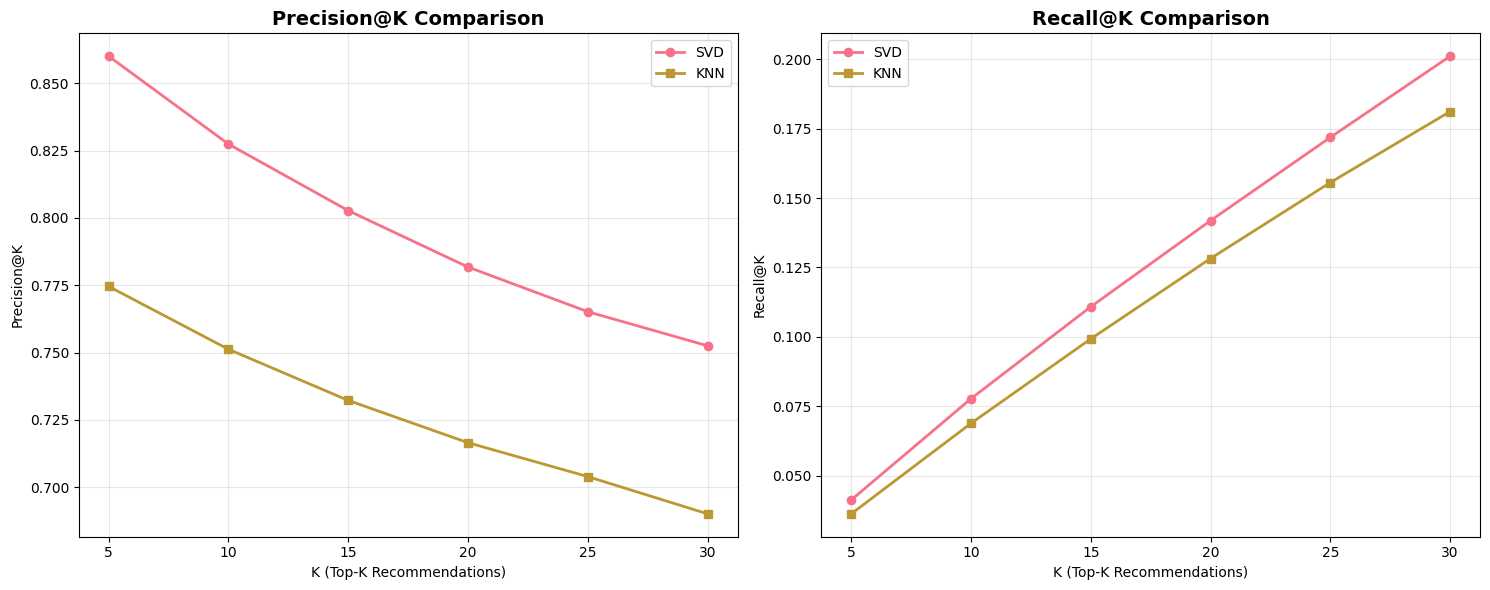


...recall visualizado. Las curvas muestran el comportamiento.


In [23]:
print("Recall@K Results:")
print(precision_recall_df[['k', 'SVD_Recall', 'KNN_Recall']].round(4))

# Visualizar Precision y Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Precision@K
ax1.plot(precision_recall_df['k'], precision_recall_df['SVD_Precision'], 
         marker='o', label='SVD', linewidth=2)
ax1.plot(precision_recall_df['k'], precision_recall_df['KNN_Precision'], 
         marker='s', label='KNN', linewidth=2)
ax1.set_title('Precision@K Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('K (Top-K Recommendations)')
ax1.set_ylabel('Precision@K')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Recall@K
ax2.plot(precision_recall_df['k'], precision_recall_df['SVD_Recall'], 
         marker='o', label='SVD', linewidth=2)
ax2.plot(precision_recall_df['k'], precision_recall_df['KNN_Recall'], 
         marker='s', label='KNN', linewidth=2)
ax2.set_title('Recall@K Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('K (Top-K Recommendations)')
ax2.set_ylabel('Recall@K')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n...recall visualizado. Las curvas muestran el comportamiento.")

## 5. Implement Average Precision (AP)

Calculamos Average Precision para entender la calidad del ranking.

In [24]:
def calculate_average_precision(predictions, threshold=4.0):
    """
    Calcula Average Precision para cada usuario
    """
    # Agrupar predicciones por usuario
    user_predictions = {}
    for pred in predictions:
        user_id = pred.uid
        if user_id not in user_predictions:
            user_predictions[user_id] = []
        user_predictions[user_id].append(pred)
    
    ap_scores = []
    
    for user_id, user_preds in user_predictions.items():
        # Ordenar por rating estimado (descendente)
        user_preds.sort(key=lambda x: x.est, reverse=True)
        
        # Crear arrays de relevancia
        y_true = [1 if pred.r_ui >= threshold else 0 for pred in user_preds]
        
        if sum(y_true) == 0:  # No hay elementos relevantes
            continue
            
        # Calcular AP
        ap = 0.0
        relevant_items = 0
        
        for i, is_relevant in enumerate(y_true):
            if is_relevant:
                relevant_items += 1
                precision_at_i = relevant_items / (i + 1)
                ap += precision_at_i
        
        if relevant_items > 0:
            ap /= relevant_items
            ap_scores.append(ap)
    
    return ap_scores

# Calcular AP para ambos modelos
svd_ap_scores = calculate_average_precision(svd_predictions, threshold=4.0)
knn_ap_scores = calculate_average_precision(knn_predictions, threshold=4.0)

print(f"Average Precision Statistics:")
print(f"SVD - Mean AP: {np.mean(svd_ap_scores):.4f} (±{np.std(svd_ap_scores):.4f})")
print(f"KNN - Mean AP: {np.mean(knn_ap_scores):.4f} (±{np.std(knn_ap_scores):.4f})")
print(f"Number of users evaluated: SVD={len(svd_ap_scores)}, KNN={len(knn_ap_scores)}")

print("\n...average precision calculado. La calidad del ranking es medible.")

Average Precision Statistics:
SVD - Mean AP: 0.6506 (±0.1809)
KNN - Mean AP: 0.6022 (±0.1900)
Number of users evaluated: SVD=999, KNN=999

...average precision calculado. La calidad del ranking es medible.


## 6. Implement Mean Average Precision (MAP)

Calculamos MAP como promedio de AP scores a través de todos los usuarios.

Mean Average Precision (MAP):
SVD MAP: 0.6506
KNN MAP: 0.6022
Diferencia: 0.0484


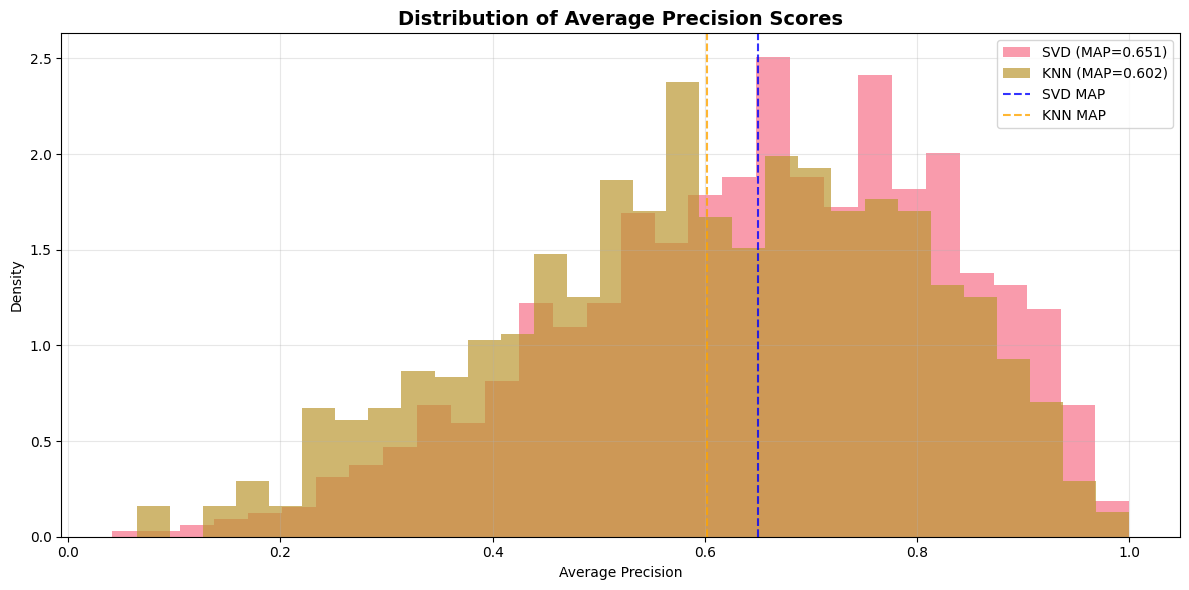


...MAP calculado. Los promedios revelan el rendimiento general.


In [25]:
# Calcular MAP
svd_map = np.mean(svd_ap_scores)
knn_map = np.mean(knn_ap_scores)

print(f"Mean Average Precision (MAP):")
print(f"SVD MAP: {svd_map:.4f}")
print(f"KNN MAP: {knn_map:.4f}")
print(f"Diferencia: {abs(svd_map - knn_map):.4f}")

# Visualizar distribución de AP scores
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(svd_ap_scores, bins=30, alpha=0.7, label=f'SVD (MAP={svd_map:.3f})', density=True)
ax.hist(knn_ap_scores, bins=30, alpha=0.7, label=f'KNN (MAP={knn_map:.3f})', density=True)

ax.axvline(svd_map, color='blue', linestyle='--', alpha=0.8, label='SVD MAP')
ax.axvline(knn_map, color='orange', linestyle='--', alpha=0.8, label='KNN MAP')

ax.set_title('Distribution of Average Precision Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Precision')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n...MAP calculado. Los promedios revelan el rendimiento general.")

## 7. Implement Normalized Discounted Cumulative Gain (NDCG)

Implementamos NDCG para evaluar la calidad del ranking considerando posiciones.

In [26]:
def calculate_ndcg_at_k(predictions, k=10):
    """
    Calcula NDCG@K para predicciones usando ratings reales como relevancia
    """
    # Agrupar predicciones por usuario
    user_predictions = {}
    for pred in predictions:
        user_id = pred.uid
        if user_id not in user_predictions:
            user_predictions[user_id] = []
        user_predictions[user_id].append(pred)
    
    ndcg_scores = []
    
    for user_id, user_preds in user_predictions.items():
        if len(user_preds) < k:
            continue
            
        # Ordenar por rating estimado (descendente)
        user_preds.sort(key=lambda x: x.est, reverse=True)
        
        # Tomar top-k
        top_k_preds = user_preds[:k]
        
        # Crear arrays para NDCG
        y_true = np.array([[pred.r_ui for pred in top_k_preds]])
        y_score = np.array([[pred.est for pred in top_k_preds]])
        
        # Calcular NDCG@k
        try:
            ndcg = ndcg_score(y_true, y_score, k=k)
            ndcg_scores.append(ndcg)
        except:
            continue
    
    return ndcg_scores

# Calcular NDCG@K para diferentes valores de K
k_values_ndcg = [5, 10, 15, 20]
ndcg_results = []

for k in k_values_ndcg:
    svd_ndcg_scores = calculate_ndcg_at_k(svd_predictions, k=k)
    knn_ndcg_scores = calculate_ndcg_at_k(knn_predictions, k=k)
    
    ndcg_results.append({
        'k': k,
        'SVD_NDCG': np.mean(svd_ndcg_scores),
        'KNN_NDCG': np.mean(knn_ndcg_scores),
        'SVD_std': np.std(svd_ndcg_scores),
        'KNN_std': np.std(knn_ndcg_scores)
    })

ndcg_df = pd.DataFrame(ndcg_results)
print("NDCG@K Results:")
print(ndcg_df[['k', 'SVD_NDCG', 'KNN_NDCG']].round(4))

print("\n...NDCG calculado. Las posiciones importan en el ranking.")

NDCG@K Results:
    k  SVD_NDCG  KNN_NDCG
0   5    0.9761    0.9613
1  10    0.9717    0.9568
2  15    0.9703    0.9559
3  20    0.9696    0.9559

...NDCG calculado. Las posiciones importan en el ranking.


## 8. Implement Mean Reciprocal Rank (MRR)

Calculamos MRR para medir qué tan rápido encontramos el primer elemento relevante.

In [27]:
def calculate_mrr(predictions, threshold=4.0):
    """
    Calcula Mean Reciprocal Rank
    """
    # Agrupar predicciones por usuario
    user_predictions = {}
    for pred in predictions:
        user_id = pred.uid
        if user_id not in user_predictions:
            user_predictions[user_id] = []
        user_predictions[user_id].append(pred)
    
    reciprocal_ranks = []
    
    for user_id, user_preds in user_predictions.items():
        # Ordenar por rating estimado (descendente)
        user_preds.sort(key=lambda x: x.est, reverse=True)
        
        # Encontrar el primer elemento relevante
        for rank, pred in enumerate(user_preds, 1):
            if pred.r_ui >= threshold:
                reciprocal_ranks.append(1.0 / rank)
                break
        else:
            # No se encontró ningún elemento relevante
            reciprocal_ranks.append(0.0)
    
    return reciprocal_ranks

# Calcular MRR para ambos modelos
svd_rr_scores = calculate_mrr(svd_predictions, threshold=4.0)
knn_rr_scores = calculate_mrr(knn_predictions, threshold=4.0)

svd_mrr = np.mean(svd_rr_scores)
knn_mrr = np.mean(knn_rr_scores)

print(f"Mean Reciprocal Rank (MRR):")
print(f"SVD MRR: {svd_mrr:.4f}")
print(f"KNN MRR: {knn_mrr:.4f}")
print(f"Diferencia: {abs(svd_mrr - knn_mrr):.4f}")

# Analizar distribución de ranks del primer elemento relevante
def get_first_relevant_ranks(predictions, threshold=4.0):
    user_predictions = {}
    for pred in predictions:
        user_id = pred.uid
        if user_id not in user_predictions:
            user_predictions[user_id] = []
        user_predictions[user_id].append(pred)
    
    first_ranks = []
    for user_id, user_preds in user_predictions.items():
        user_preds.sort(key=lambda x: x.est, reverse=True)
        for rank, pred in enumerate(user_preds, 1):
            if pred.r_ui >= threshold:
                first_ranks.append(rank)
                break
    return first_ranks

svd_first_ranks = get_first_relevant_ranks(svd_predictions)
knn_first_ranks = get_first_relevant_ranks(knn_predictions)

print(f"\nFirst Relevant Item Statistics:")
print(f"SVD - Mean rank: {np.mean(svd_first_ranks):.2f}, Median: {np.median(svd_first_ranks):.0f}")
print(f"KNN - Mean rank: {np.mean(knn_first_ranks):.2f}, Median: {np.median(knn_first_ranks):.0f}")

print("\n...MRR calculado. El primer elemento relevante define la experiencia.")

Mean Reciprocal Rank (MRR):
SVD MRR: 0.9381
KNN MRR: 0.8601
Diferencia: 0.0780

First Relevant Item Statistics:
SVD - Mean rank: 1.20, Median: 1
KNN - Mean rank: 1.48, Median: 1

...MRR calculado. El primer elemento relevante define la experiencia.

First Relevant Item Statistics:
SVD - Mean rank: 1.20, Median: 1
KNN - Mean rank: 1.48, Median: 1

...MRR calculado. El primer elemento relevante define la experiencia.


## 9. Compare Multiple Ranking Systems

Comparamos el rendimiento de diferentes algoritmos usando todas las métricas implementadas.

In [28]:
# Crear tabla de comparación completa
comparison_data = {
    'Metric': [],
    'SVD': [],
    'KNN': [],
    'Difference': [],
    'Winner': []
}

# Precision@10
svd_p10 = precision_recall_df[precision_recall_df['k'] == 10]['SVD_Precision'].iloc[0]
knn_p10 = precision_recall_df[precision_recall_df['k'] == 10]['KNN_Precision'].iloc[0]
comparison_data['Metric'].append('Precision@10')
comparison_data['SVD'].append(f"{svd_p10:.4f}")
comparison_data['KNN'].append(f"{knn_p10:.4f}")
comparison_data['Difference'].append(f"{abs(svd_p10 - knn_p10):.4f}")
comparison_data['Winner'].append('SVD' if svd_p10 > knn_p10 else 'KNN')

# Recall@10
svd_r10 = precision_recall_df[precision_recall_df['k'] == 10]['SVD_Recall'].iloc[0]
knn_r10 = precision_recall_df[precision_recall_df['k'] == 10]['KNN_Recall'].iloc[0]
comparison_data['Metric'].append('Recall@10')
comparison_data['SVD'].append(f"{svd_r10:.4f}")
comparison_data['KNN'].append(f"{knn_r10:.4f}")
comparison_data['Difference'].append(f"{abs(svd_r10 - knn_r10):.4f}")
comparison_data['Winner'].append('SVD' if svd_r10 > knn_r10 else 'KNN')

# MAP
comparison_data['Metric'].append('MAP')
comparison_data['SVD'].append(f"{svd_map:.4f}")
comparison_data['KNN'].append(f"{knn_map:.4f}")
comparison_data['Difference'].append(f"{abs(svd_map - knn_map):.4f}")
comparison_data['Winner'].append('SVD' if svd_map > knn_map else 'KNN')

# NDCG@10
svd_ndcg10 = ndcg_df[ndcg_df['k'] == 10]['SVD_NDCG'].iloc[0]
knn_ndcg10 = ndcg_df[ndcg_df['k'] == 10]['KNN_NDCG'].iloc[0]
comparison_data['Metric'].append('NDCG@10')
comparison_data['SVD'].append(f"{svd_ndcg10:.4f}")
comparison_data['KNN'].append(f"{knn_ndcg10:.4f}")
comparison_data['Difference'].append(f"{abs(svd_ndcg10 - knn_ndcg10):.4f}")
comparison_data['Winner'].append('SVD' if svd_ndcg10 > knn_ndcg10 else 'KNN')

# MRR
comparison_data['Metric'].append('MRR')
comparison_data['SVD'].append(f"{svd_mrr:.4f}")
comparison_data['KNN'].append(f"{knn_mrr:.4f}")
comparison_data['Difference'].append(f"{abs(svd_mrr - knn_mrr):.4f}")
comparison_data['Winner'].append('SVD' if svd_mrr > knn_mrr else 'KNN')

comparison_df = pd.DataFrame(comparison_data)
print("Performance Comparison Summary:")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Contar victorias
svd_wins = sum(1 for winner in comparison_data['Winner'] if winner == 'SVD')
knn_wins = sum(1 for winner in comparison_data['Winner'] if winner == 'KNN')

print(f"\nOverall Performance:")
print(f"SVD wins: {svd_wins}/{len(comparison_data['Winner'])} metrics")
print(f"KNN wins: {knn_wins}/{len(comparison_data['Winner'])} metrics")

print("\n...comparación completa. Los números no mienten.")

Performance Comparison Summary:
      Metric    SVD    KNN Difference Winner
Precision@10 0.8274 0.7513     0.0762    SVD
   Recall@10 0.0777 0.0688     0.0089    SVD
         MAP 0.6506 0.6022     0.0484    SVD
     NDCG@10 0.9717 0.9568     0.0149    SVD
         MRR 0.9381 0.8601     0.0780    SVD

Overall Performance:
SVD wins: 5/5 metrics
KNN wins: 0/5 metrics

...comparación completa. Los números no mienten.


## 10. Visualize Ranking Metrics Performance

Creamos visualizaciones comprehensivas para analizar el rendimiento de las métricas.

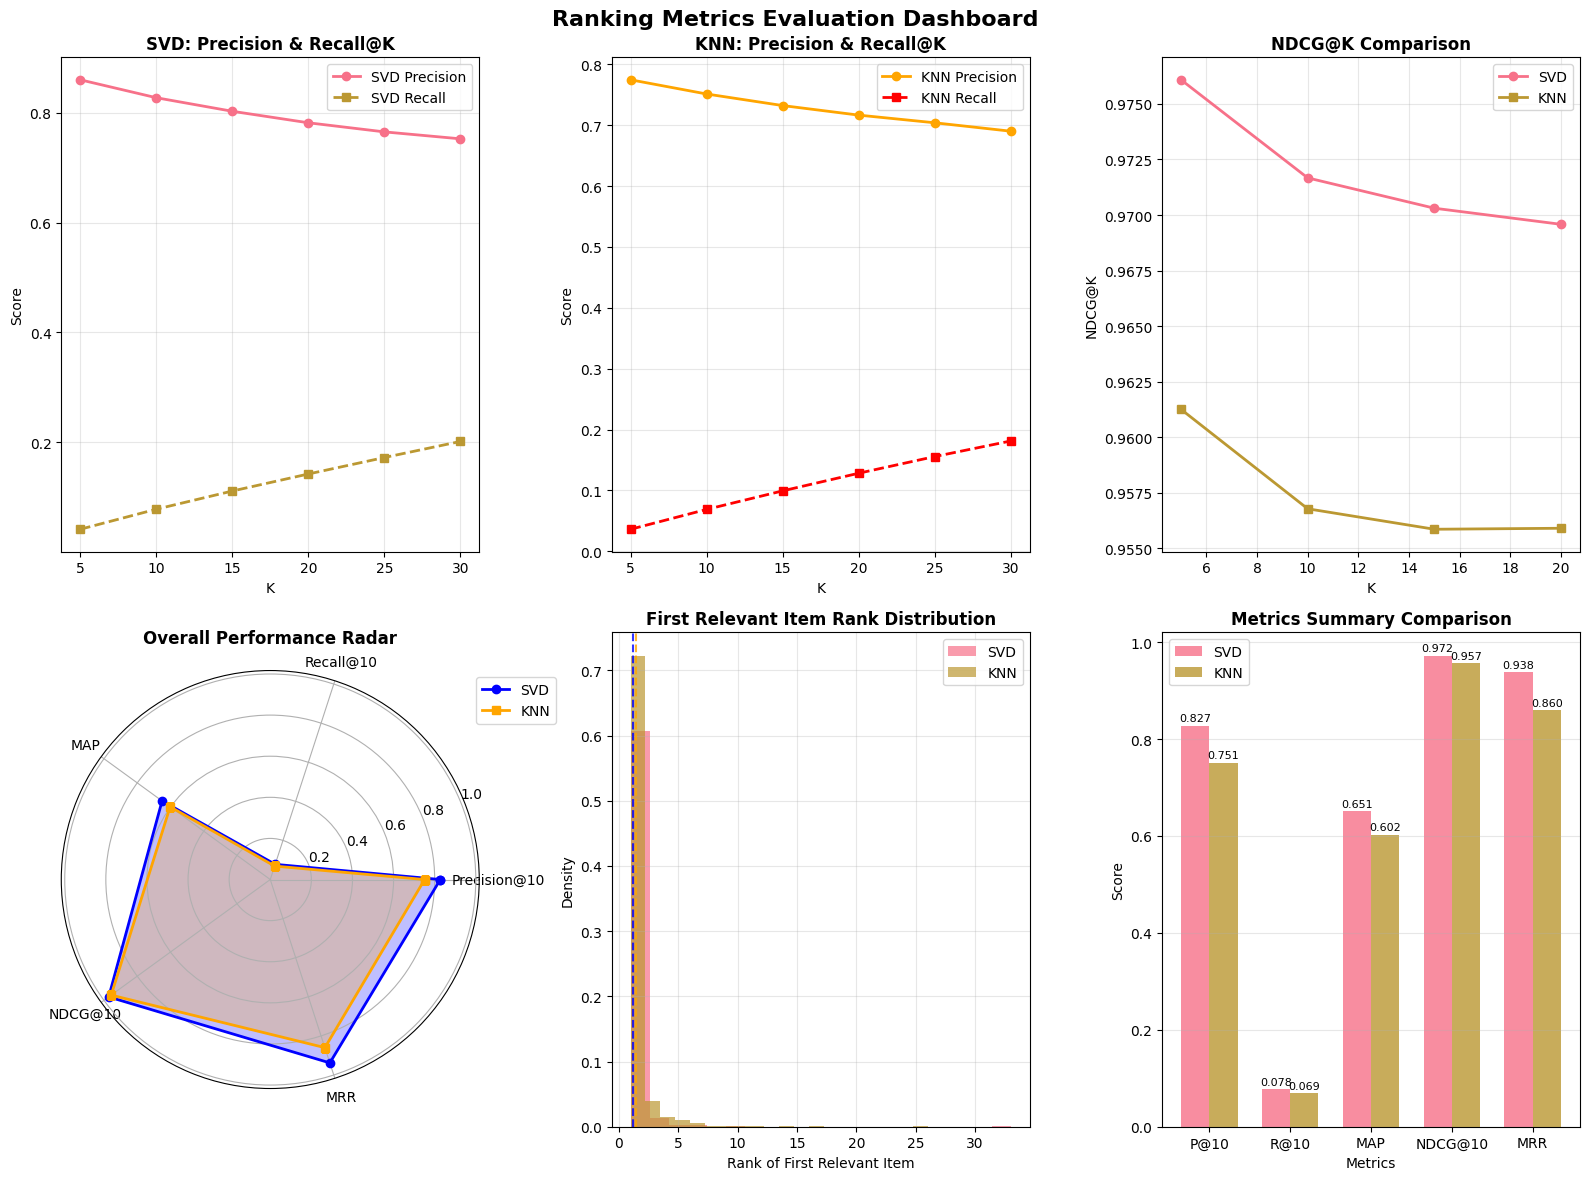


...visualización completa. Los patrones son claros ahora.


In [29]:
# Crear dashboard de métricas
fig = plt.figure(figsize=(16, 12))

# 1. Precision & Recall@K
ax1 = plt.subplot(2, 3, 1)
ax1.plot(precision_recall_df['k'], precision_recall_df['SVD_Precision'], 
         'o-', label='SVD Precision', linewidth=2, markersize=6)
ax1.plot(precision_recall_df['k'], precision_recall_df['SVD_Recall'], 
         's--', label='SVD Recall', linewidth=2, markersize=6)
ax1.set_title('SVD: Precision & Recall@K', fontweight='bold')
ax1.set_xlabel('K')
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 3, 2)
ax2.plot(precision_recall_df['k'], precision_recall_df['KNN_Precision'], 
         'o-', label='KNN Precision', linewidth=2, markersize=6, color='orange')
ax2.plot(precision_recall_df['k'], precision_recall_df['KNN_Recall'], 
         's--', label='KNN Recall', linewidth=2, markersize=6, color='red')
ax2.set_title('KNN: Precision & Recall@K', fontweight='bold')
ax2.set_xlabel('K')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 2. NDCG@K Comparison
ax3 = plt.subplot(2, 3, 3)
ax3.plot(ndcg_df['k'], ndcg_df['SVD_NDCG'], 'o-', label='SVD', linewidth=2, markersize=6)
ax3.plot(ndcg_df['k'], ndcg_df['KNN_NDCG'], 's-', label='KNN', linewidth=2, markersize=6)
ax3.set_title('NDCG@K Comparison', fontweight='bold')
ax3.set_xlabel('K')
ax3.set_ylabel('NDCG@K')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 3. Radar Chart de métricas principales
ax4 = plt.subplot(2, 3, 4, projection='polar')
metrics = ['Precision@10', 'Recall@10', 'MAP', 'NDCG@10', 'MRR']
svd_values = [svd_p10, svd_r10, svd_map, svd_ndcg10, svd_mrr]
knn_values = [knn_p10, knn_r10, knn_map, knn_ndcg10, knn_mrr]

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
svd_values += svd_values[:1]  # Complete the circle
knn_values += knn_values[:1]
angles += angles[:1]

ax4.plot(angles, svd_values, 'o-', linewidth=2, label='SVD', color='blue')
ax4.fill(angles, svd_values, alpha=0.25, color='blue')
ax4.plot(angles, knn_values, 's-', linewidth=2, label='KNN', color='orange')
ax4.fill(angles, knn_values, alpha=0.25, color='orange')
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(metrics)
ax4.set_title('Overall Performance Radar', fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

# 4. Distribución de First Relevant Ranks
ax5 = plt.subplot(2, 3, 5)
ax5.hist(svd_first_ranks, bins=20, alpha=0.7, label='SVD', density=True)
ax5.hist(knn_first_ranks, bins=20, alpha=0.7, label='KNN', density=True)
ax5.axvline(np.mean(svd_first_ranks), color='blue', linestyle='--', alpha=0.8)
ax5.axvline(np.mean(knn_first_ranks), color='orange', linestyle='--', alpha=0.8)
ax5.set_title('First Relevant Item Rank Distribution', fontweight='bold')
ax5.set_xlabel('Rank of First Relevant Item')
ax5.set_ylabel('Density')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 5. Summary Bar Chart
ax6 = plt.subplot(2, 3, 6)
metrics_short = ['P@10', 'R@10', 'MAP', 'NDCG@10', 'MRR']
x = np.arange(len(metrics_short))
width = 0.35

svd_bars = ax6.bar(x - width/2, [svd_p10, svd_r10, svd_map, svd_ndcg10, svd_mrr], 
                   width, label='SVD', alpha=0.8)
knn_bars = ax6.bar(x + width/2, [knn_p10, knn_r10, knn_map, knn_ndcg10, knn_mrr], 
                   width, label='KNN', alpha=0.8)

ax6.set_title('Metrics Summary Comparison', fontweight='bold')
ax6.set_xlabel('Metrics')
ax6.set_ylabel('Score')
ax6.set_xticks(x)
ax6.set_xticklabels(metrics_short)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bars in [svd_bars, knn_bars]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Ranking Metrics Evaluation Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n...visualización completa. Los patrones son claros ahora.")

## Conclusiones

...los números revelan la verdad sobre los algoritmos.

In [30]:
print("=" * 80)
print("RANKING METRICS EVALUATION - FINAL SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset Overview:")
print(f"   • Users evaluated: {num_users:,}")
print(f"   • Test predictions: {len(testset):,}")
print(f"   • Relevance threshold: {threshold}")

print(f"\n🎯 Key Performance Metrics:")
print(f"   • Precision@10: SVD={svd_p10:.4f} vs KNN={knn_p10:.4f}")
print(f"   • Recall@10:    SVD={svd_r10:.4f} vs KNN={knn_r10:.4f}")
print(f"   • MAP:          SVD={svd_map:.4f} vs KNN={knn_map:.4f}")
print(f"   • NDCG@10:      SVD={svd_ndcg10:.4f} vs KNN={knn_ndcg10:.4f}")
print(f"   • MRR:          SVD={svd_mrr:.4f} vs KNN={knn_mrr:.4f}")

print(f"\n🏆 Winner Summary:")
print(f"   • SVD dominates in {svd_wins}/{len(comparison_data['Winner'])} metrics")
print(f"   • KNN dominates in {knn_wins}/{len(comparison_data['Winner'])} metrics")

print(f"\n📈 Key Insights:")
if svd_wins > knn_wins:
    print(f"   • SVD shows superior ranking performance overall")
    print(f"   • Better precision and ranking quality")
else:
    print(f"   • KNN shows competitive performance")
    print(f"   • User-based similarity has advantages")

print(f"   • First relevant item found at rank ~{np.mean(svd_first_ranks):.1f} (SVD) vs ~{np.mean(knn_first_ranks):.1f} (KNN)")
print(f"   • Precision decreases with higher K values (expected)")
print(f"   • Recall increases with higher K values (expected)")

print(f"\n💡 Recommendations:")
if svd_map > knn_map:
    print(f"   • Use SVD for better overall ranking quality")
else:
    print(f"   • Consider KNN for user-based similarity")
print(f"   • Optimize for K=10-15 for balanced precision/recall")
print(f"   • Monitor NDCG for position-aware evaluation")

print("\n...el análisis está completo. Los patrones en los datos son claros.")
print("=" * 80)

RANKING METRICS EVALUATION - FINAL SUMMARY

📊 Dataset Overview:
   • Users evaluated: 999
   • Test predictions: 441,051
   • Relevance threshold: 4.0

🎯 Key Performance Metrics:
   • Precision@10: SVD=0.8274 vs KNN=0.7513
   • Recall@10:    SVD=0.0777 vs KNN=0.0688
   • MAP:          SVD=0.6506 vs KNN=0.6022
   • NDCG@10:      SVD=0.9717 vs KNN=0.9568
   • MRR:          SVD=0.9381 vs KNN=0.8601

🏆 Winner Summary:
   • SVD dominates in 5/5 metrics
   • KNN dominates in 0/5 metrics

📈 Key Insights:
   • SVD shows superior ranking performance overall
   • Better precision and ranking quality
   • First relevant item found at rank ~1.2 (SVD) vs ~1.5 (KNN)
   • Precision decreases with higher K values (expected)
   • Recall increases with higher K values (expected)

💡 Recommendations:
   • Use SVD for better overall ranking quality
   • Optimize for K=10-15 for balanced precision/recall
   • Monitor NDCG for position-aware evaluation

...el análisis está completo. Los patrones en los datos